### Porównanie Adam vs SGD 

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#### 1. Wczytanie i przygotowanie danych

In [4]:
breast_cancer = load_breast_cancer()
x, y = breast_cancer.data, breast_cancer.target

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=1
)

In [5]:
# Skalowanie danych 
sc = StandardScaler()
x_train = torch.tensor(sc.fit_transform(x_train), dtype=torch.float32)
x_test = torch.tensor(sc.transform(x_test), dtype=torch.float32)

In [9]:
# Zamiana etykiet na macierze 2D
y_train = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)
y_test = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)

#### 2. Definicja modelu

In [12]:
class BreastCancerClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        # jedna warstwa liniowa
        self.linear = nn.Linear(input_dim, 1)
        # funkcja aktywacji sigmoid – przekształca w [0,1]
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # forward pass: x → linear → sigmoid
        return self.sigmoid(self.linear(x))

input_dim = x_train.shape[1]  # 30 cech

#### 3. Funkcja trenowania

In [15]:
def train_model(optimizer_name, epochs=50, lr=0.01):
    """
    Trenuje model z zadanym optymalizatorem
    Zwraca historię strat i dokładność na zbiorze testowym
    """
    model = BreastCancerClassifier(input_dim)
    
    criterion = nn.BCELoss()  # Binary Cross Entropy
    
    # Wybór optymalizatora
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr)
    
    losses = []
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()  # reset gradientów
        y_pred = model(x_train)
        loss = criterion(y_pred, y_train)  # obliczenie straty
        loss.backward()  # backprop – gradienty
        optimizer.step()  # aktualizacja wag
        losses.append(loss.item())
    
    # Ewaluacja na zbiorze testowym
    model.eval()
    with torch.no_grad():
        y_pred_test = model(x_test)
        y_pred_round = y_pred_test.round()  # 0 lub 1
        acc = (y_pred_round.eq(y_test).sum() / float(y_test.shape[0])).item()
    
    return losses, acc

#### 4. Trenowanie modeli

In [18]:
adam_losses, adam_acc = train_model("Adam")
sgd_losses, sgd_acc = train_model("SGD")

#### 5. Wizualizacja strat

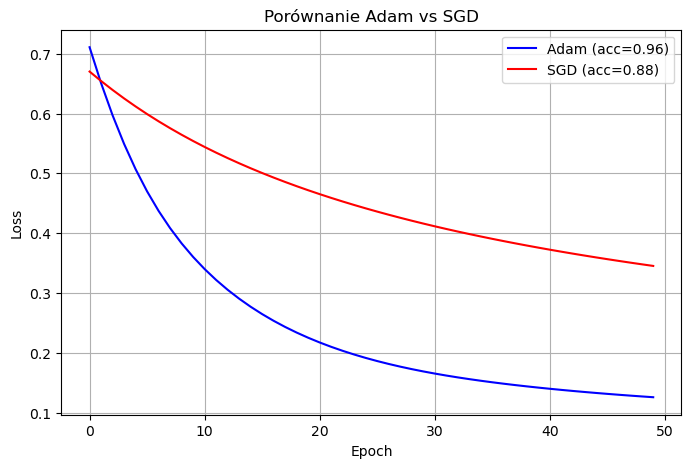

In [21]:
plt.figure(figsize=(8,5))
plt.plot(adam_losses, label=f'Adam (acc={adam_acc:.2f})', color='blue')
plt.plot(sgd_losses, label=f'SGD (acc={sgd_acc:.2f})', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Porównanie Adam vs SGD')
plt.legend()
plt.grid(True)
plt.show()